## Finding observations of Mars in the CADC archive

S. Erard, March 2026, adapted from Baptiste Cecconi, Nov 2025 on Jupiter (https://github.com/epn-vespa/tutorials/blob/master/misc/searching_archives/stmoc-jupiter.ipynb)


The Jupiter example is generalized to extract data products related to a longer period, typically over a complete Martian year (centered on the close opposition of 2003).
This requires to optimize the request to the archive and the MOC computation time.

Changes wrt the initial Jupiter example :
- the TAP request is filtered in ecliptic longitude (restained to a narrow ecliptic band)
- the MOC computation uses another, faster method (from_cones) adapted to long periods (i.e. significant part of the orbit)
- assement is provided through comparison with the EPN-TAP HST_planeto service for several trajectory parameters


In [1]:
import requests
from astropy.time import Time, TimeDelta
from astropy.coordinates import SkyCoord
from astropy.table import Table
import astropy.units as u
import numpy
from mocpy import MOC, STMOC, TimeMOC

from pathlib import Path
DATADIR = Path('.') / "data" 
DATADIR.mkdir(exist_ok=True)

# LTE ephemeris webservices

The LTE lab (https://lte.observatoiredeparis.psl.eu) is proposing a Solar System Ephemeris (https://ssp.imcce.fr/webservices/). 

We will use here the Miriade `ephemcc` webservice (for positional ephemerides)

Review the API configuration at https://ssp.imcce.fr/webservices/miriade/api/ephemcc/

Fill in the following query parameters for: 
- Target: Mars
- Observer: Hubble Space Telescope
- Start time: 1st Jul 2002
- Stop time: 30 Sept 2004 (~ 1 Martian year centered around 2003 opposition)
- 10 min step for ~ 2 years (720 days)
- select the "votable" output format

NB: each field has specific syntax, as described in the API specification (see link above) 

In [25]:
dt = 10 * u.minute  # sampling time, minutes

ephemcc_url = "https://ssp.imcce.fr/webservices/miriade/api/ephemcc.php?"
ephemcc_params = {
    "-name": "p:Mars",
    "-observer": "hst",
    "-ep": "2002-07-01T00:00:00",
    "-nbd": f"{720*24*6}",
    "-step": f"{int(dt.value)}m",
    "-from": "VESPA-test",
    "-mime": "votable",
}

In [26]:
query = ephemcc_url+"&".join([f"{k}={v}" for k,v in ephemcc_params.items()])
print(query)

https://ssp.imcce.fr/webservices/miriade/api/ephemcc.php?-name=p:Mars&-observer=05&-ep=2002-07-01T00:00:00&-nbd=103680&-step=10m&-from=VESPA-test&-mime=votable


**In order to avoid overloading the LTE servers, update the `recompute` flag once you are happy with your dataset**

In [27]:
output_file = DATADIR / "mars-ephemccB.xml"
recompute = False
#recompute = True

if recompute:
    resp = requests.get(query)
    with open(output_file, 'w') as f:
        f.write(resp.content.decode())

The data is available in a VOTable file. 

The `Table` object of astropy can read such file, with the format option "votable". 

more info: https://docs.astropy.org/en/stable/table/index.html 

In [5]:
data = Table.read(output_file, format="votable")

Using the astropy `Time` object construct 2 variables containing the start and end times of each interval of the ephemcc query result.  

More info: https://docs.astropy.org/en/stable/time/index.html

The start times (named `times_start`) are the ephemeris times, and the end times (named `times_and`) are the same, with 1 time step added. So that we get a full list of intervals filling the overall studied time period.   

In [6]:
times_start = Time([d for d in data["date"].data], format='isot')
times_end = times_start + TimeDelta(dt.to(u.s), format="sec")

Using the astropy `SkyCoord` object construct the series of positions for each ephemeris computation. 

More info: https://docs.astropy.org/en/stable/coordinates/index.html

Name your position variable `positions`. Also extract the distance of the target (variable `distances`) 

In [7]:
positions = SkyCoord(data["RA"], data["DEC"], unit=(u.hourangle, u.deg))
distances = data['dobs']

Check the units of the `distances` variable and convert to `km` 

In [8]:
distances.to('km').value

array([3.90248065e+08, 3.90247871e+08, 3.90250123e+08, ...,
       3.70035719e+08, 3.70041856e+08, 3.70050327e+08], shape=(103680,))

Compute the size of Mars (check the values in *arcsec*), using the Mars radius = 3390 km 

In [9]:
sizes = numpy.atan2(3390, distances.to(u.km).value) * u.rad * 2
sizes.to(u.arcsec)

<Quantity [3.58355495, 3.58355673, 3.58353606, ..., 3.77929836, 3.77923569,
           3.77914917] arcsec>

**The sampled trajectory is easily plotted in TOPCAT**

- The trajectory traces a large loop around the opposition, which corresponds to Mars retrograde motion as the Earth overtakes it from the inside
- Small variations with a quasi-period of ~90 min also trace small loops near opposition with amplitude ~ 25". This is the daily parallax observed from HST's orbit — the same effect is observed from ground telescopes with a 24h period. It is particularly noticeable during this extremely close opposition.

<img src=data/Mars20203_HST.png width=400 height=400 />


**Define which MOC order should be used to have a MOC resolution consistent with the data.**

(NB: a too low order will over estimate the footprints, a too high order will take a long time to compute. This must be optimised together with time sampling step).

In [10]:
moc_order = 12
# 13 corresponds to 26" on the sky, ~ disk size at opposition that year (no need to fit very distant configurations, they are close to the Sun)
# Order 12 may be better suited to grab all data files

Now we compute the STMOC objects (and additional merged TMOC and MOC objects) 

Documentation on MOC: 
- IVOA Specification: https://www.ivoa.net/documents/MOC/
- MocPy library: https://cds-astro.github.io/mocpy/index.html

In [11]:
# verif à la volée
len(data)
dec = positions.dec
ra = positions.ra
spatial_coverages = [
    MOC.from_cones(ra, dec, radius=sizes.to(u.deg)/2, max_depth=moc_order)
]
#spatial_coverages[0]
len(spatial_coverages[0])

103680

In [12]:
%%time
#spatial_coverages = [
#    MOC.from_cone(pos.ra, pos.dec, radius=siz.to(u.deg)/2, max_depth=moc_order)
#    for pos, siz in zip(positions, sizes)
#]

#stmoc_ephemcc = STMOC.from_spatial_coverages(
#    times_start,
#    times_end,
#    spatial_coverages,
#)

# other method, faster (beware of changing list format)
dec = positions.dec
ra = positions.ra
spatial_coverages = [
    MOC.from_cones(ra, dec, radius=sizes.to(u.deg)/2, max_depth=moc_order)
]

stmoc_ephemcc = STMOC.from_spatial_coverages(
    times_start,
    times_end,
    spatial_coverages[0],
)

tmoc_ephemcc = TimeMOC.from_time_ranges(
    times_start[0],
    times_end[-1]
)

moc_ephemcc = stmoc_ephemcc.query_by_time(tmoc_ephemcc)
#assessments
#print(spatial_coverages)
#moc_strings = [m.to_string() for m in spatial_coverages[0]]
#moc_str = string = ' '.join(moc_strings)
#moc_str
#moc_ephemcc.save('MOCephem.txt', format='ascii')
#moc_ephemcc.save('MOCephem_o12.txt', format='ascii')
#stmoc_ephemcc.save('STMOCephem.fits', format='fits')

CPU times: user 741 ms, sys: 162 ms, total: 903 ms
Wall time: 620 ms


We can display the STMOC ranges: 

In [13]:
print("STMOC min time:", Time(tmoc_ephemcc.min_time.mjd[0], format='mjd').isot)
print("STMOC max time:", Time(tmoc_ephemcc.max_time.mjd[-1], format='mjd').isot)
print("Declination min /max:", min(positions.dec), max(positions.dec))

# convert to ecliptic coord
coord_ecl=positions.transform_to('geocentricmeanecliptic')
print("Eclip lat min /max:", min(coord_ecl.lat), max(coord_ecl.lat))


STMOC min time: 2002-07-01T00:00:12.931
STMOC max time: 2004-06-20T00:05:19.246
Declination min /max: -23d34m23.7232s 24d40m29.8586s
Eclip lat min /max: -6d42m32.80289236s 1d14m51.9819038s


# Query a TAP service for HST data

1) use the `https://hst.esac.esa.int/tap-server/tap` TAP server and query the `ivoa.ObsCore` table, with a time interval selection on parameters `tmin` and `tmax` (which are in `mjd` - Modified Julian Date).

In Feb 2026, the ESA service is down. We use the CADC service instead `https://ws.cadc-ccda.hia-iha.nrc-cnrc.gc.ca/argus`

2) The strategy is to narrow the TAP request as much as possible to speed up the MOC computation later.

In addition, we therefore:
- request the period of interest
- request the range of interest in spatial coordinates (this is very efficient to restrain the result size and speed up later operations, as the planets have limited excursion)
- use ecliptic latitude as spatial filter, rather than declination (much narrower excursion for planets)
- filter on processing level (and possibly other restrictions on product types)

In the query, you can retreive the following parameters: 
- `access_url`: URL to access the data
- `calib_level`: calibration level
- `dataproduct_type`: data product type (i.e.: image, spectrum...)
- `em_min`: lower bound of the spectral range (wavelength in m)
- `em_max`: upper bound of the spectral range (wavelength in m)
- `facility_name`: name of the observing facility
- `instrument_name`: name of the instrument
- `obs_collection`: name of the observation collection, as defined by the instrument operator
- `obs_id`: identifier of the observation
- `obs_publisher_did`: identifier of the data object as defined by the publisher
- `s_dec`: spatial coordinate (Declination)
- `s_ra`: spatial coordinate (Right Ascension)
- `s_fov`: spatial field-of-view diameter (in degrees)
- `s_region`: spatial region observed (in STCS format)
- `t_min`: lower bound of the temporal coverage in MJD
- `t_max`: upper bound of the temporal coverage in MJD
- `target_name`: name of the target, as defined by the observer

for more details on the `ObsCore` parameters specification, see here: https://ivoa.net/documents/ObsCore/  



In [14]:
from pyvo.dal import TAPService

In [15]:
tap_service = TAPService("https://hst.esac.esa.int/tap-server/tap")
# use CADC server, OK but contains more than HST (ESA HST seems down in Feb 2026)
tap_service = TAPService("https://ws.cadc-ccda.hia-iha.nrc-cnrc.gc.ca/argus")

In [16]:
query = f"""
     SELECT access_url, calib_level, dataproduct_type,
            em_min, em_max, facility_name, instrument_name,
            obs_collection, obs_id, obs_publisher_did, s_dec,
            s_fov, s_ra, s_region, t_min, t_max, target_name, 
            DEGREES( ASIN(
      SIN(RADIANS(s_dec)) * COS(RADIANS(23.43928))
      - COS(RADIANS(s_dec)) * SIN(RADIANS(23.43928)) * SIN(RADIANS(s_ra)))  ) AS lat_ecliptique
     FROM ivoa.ObsCore
     WHERE t_max >= {tmoc_ephemcc.min_time.mjd[0]}
     and t_min <= {tmoc_ephemcc.max_time.mjd[0]}
     and t_min > 0
     and s_region IS NOT NULL
     and calib_level between 2 and 3
     and   DEGREES(
    ASIN(
      SIN(RADIANS(s_dec)) * COS(RADIANS(23.43928))
      - COS(RADIANS(s_dec)) * SIN(RADIANS(23.43928)) * SIN(RADIANS(s_ra))
    )
  ) BETWEEN -7 AND 2

     and obs_collection = 'HST'
"""
# We here restrain to the std HST collection for comparison with the EPN-TAP service
print(query)


     SELECT access_url, calib_level, dataproduct_type,
            em_min, em_max, facility_name, instrument_name,
            obs_collection, obs_id, obs_publisher_did, s_dec,
            s_fov, s_ra, s_region, t_min, t_max, target_name, 
            DEGREES( ASIN(
      SIN(RADIANS(s_dec)) * COS(RADIANS(23.43928))
      - COS(RADIANS(s_dec)) * SIN(RADIANS(23.43928)) * SIN(RADIANS(s_ra)))  ) AS lat_ecliptique
     FROM ivoa.ObsCore
     WHERE t_max >= 52456.00014966518
     and t_min <= 53176.00369498074
     and t_min > 0
     and s_region IS NOT NULL
     and calib_level between 2 and 3
     and   DEGREES(
    ASIN(
      SIN(RADIANS(s_dec)) * COS(RADIANS(23.43928))
      - COS(RADIANS(s_dec)) * SIN(RADIANS(23.43928)) * SIN(RADIANS(s_ra))
    )
  ) BETWEEN -7 AND 2

     and obs_collection = 'HST'



In [17]:
%%time
obscore_file = DATADIR / "hst-obscoreMars5.xml"
recompute = False
#recompute = True

if recompute:
    result = tap_service.search(query)
    with open(obscore_file, 'w') as f:
        result.votable.to_xml(f)

CPU times: user 8 μs, sys: 1 μs, total: 9 μs
Wall time: 10 μs


In [18]:
obscore = Table.read(obscore_file, format="votable")

For computing the STMOC, we use the `s_region` column of the TAP result, using the `MOC.from_stcs()` method.
*Hint*: STMOC are readily displayed in Aladin, using the menu item View > Create a time view

In [19]:
%%time

spatial_coverages = [
    MOC.from_stcs(s_region, max_depth=moc_order)
    for s_region in obscore['s_region'] 
]

stmoc_observation = STMOC.from_spatial_coverages(
    Time(obscore['t_min'], format='mjd'),
    Time(obscore['t_max'], format='mjd'),
    spatial_coverages
)

tmoc_observation = TimeMOC.from_time_ranges(
    Time(min(obscore['t_min']), format='mjd'),
    Time(max(obscore['t_max']), format='mjd')
)

moc_observation = stmoc_observation.query_by_time(tmoc_observation)

CPU times: user 2.84 s, sys: 12.1 s, total: 14.9 s
Wall time: 2.4 s


In [20]:
# Helper function for displaying the MOCs

from astropy.visualization.wcsaxes.frame import EllipticalFrame

def plot(moc, title=""):
    """Create a plot of a MOC."""
    import matplotlib.pyplot as plt

    fig = plt.figure(figsize=(15, 10))

    from astropy.wcs import WCS

    wcs = WCS(naxis=2)
    wcs.wcs.ctype = ["RA---AIT", "DEC--AIT"]
    wcs.wcs.crval = [110.0, 0.0]
    wcs.wcs.cdelt = [-0.675, 0.675]
    wcs.wcs.crpix = [240.5, 120.5]

    ax = fig.add_subplot(1, 1, 1, projection=wcs, frame_class=EllipticalFrame)

    moc.fill(
        ax=ax,
        wcs=wcs,
        edgecolor="r",
        facecolor="r",
        linewidth=1.0,
        fill=True,
        alpha=0.5,
    )
    moc.border(ax=ax, wcs=wcs, color="black", alpha=0.5)

    ax.set_aspect(1.0)

    plt.xlabel("ra")
    plt.ylabel("dec")
    if title:
        plt.title(title)
    plt.grid(color="black", linestyle="dotted")
    plt.show()
    plt.close()


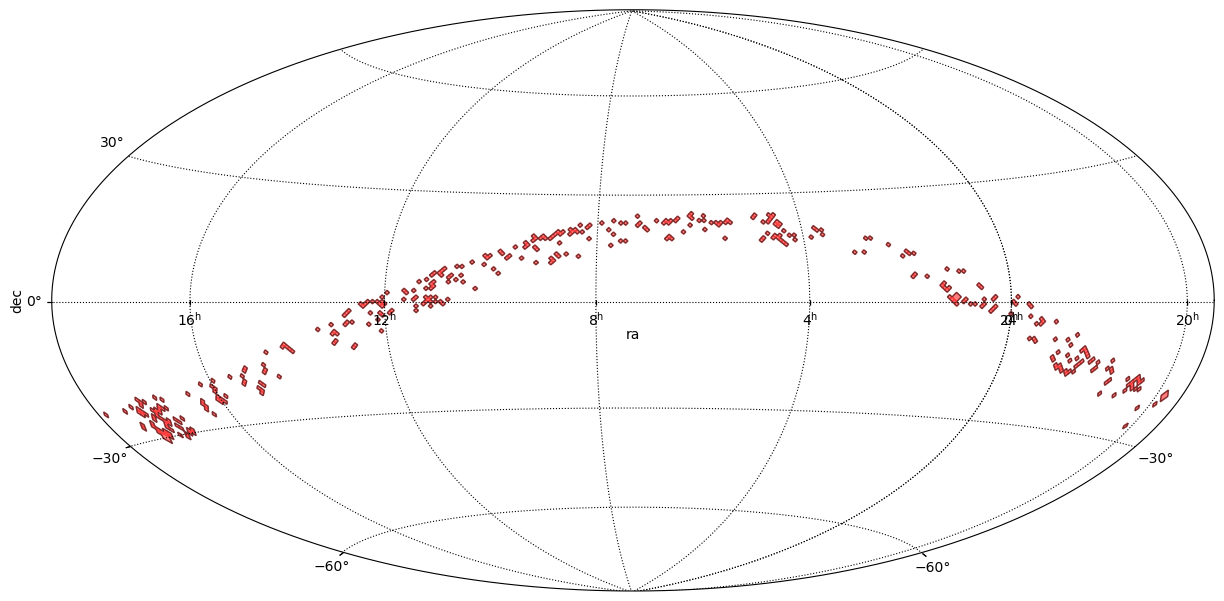

In [21]:
plot(moc_observation)

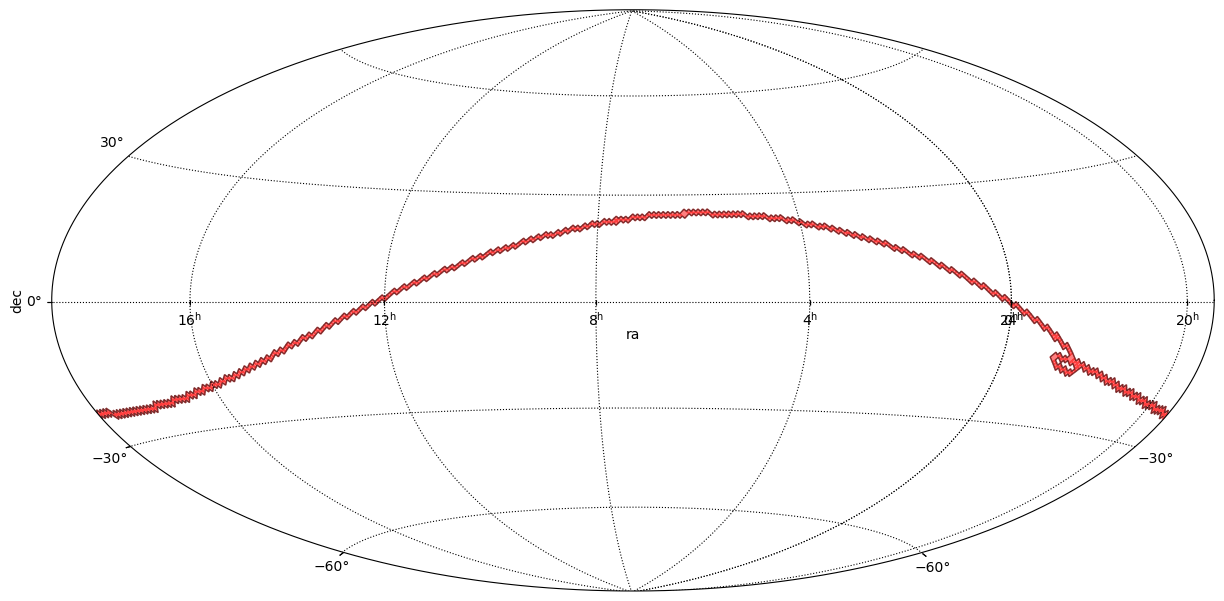

In [22]:
plot(moc_ephemcc)

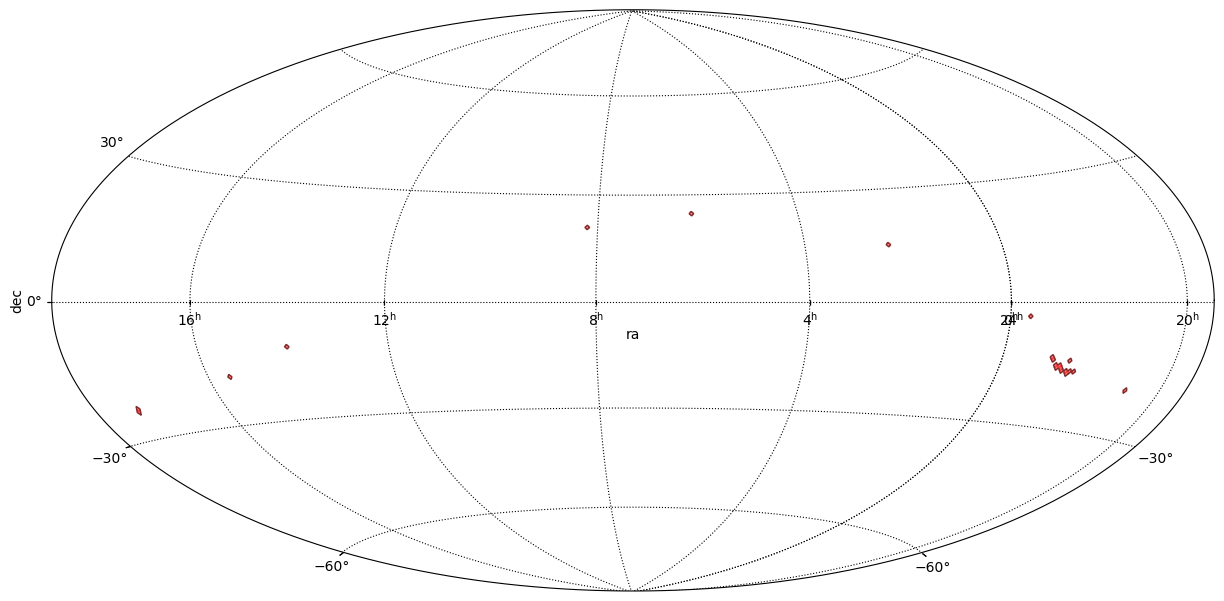

In [23]:
plot(moc_observation.intersection(moc_ephemcc))

Since the TAP query includes all observations of the time interval, we want to remove HST observations not targeting Mars.

Build a mask array (`True` = Mars is in field of view). Use the `.intersection()` method iteratively. This step is rather slow.

In [24]:
%%time
mask = []
for row, cov in zip(obscore, spatial_coverages):
    stmoc_row = STMOC.from_spatial_coverages(
        Time(row['t_min'], format='mjd'),
        Time(row['t_max'], format='mjd'),
        cov
    )
    if stmoc_row.intersection(stmoc_ephemcc).is_empty():
        mask.append(False)
    else:
        print(row['obs_id'], row['calib_level'], row['obs_collection'], row['target_name'])
        mask.append(True)

u8ta0103m 2 HST MARS
u8p70706m 2 HST MARS-2003-WFPC2-3
u8p70409m 2 HST MARS-2003-WFPC2-2
u8p70704m 2 HST MARS-2003-WFPC2-3
u8p70407m 2 HST MARS-2003-WFPC2-2
u8p70106m 2 HST MARS-2003-WFPC2-1
u8p70103m 2 HST MARS-2003-WFPC2-1
u8ta0104m 2 HST MARS
u8ta0207m 2 HST MARS
u8ta0106m 2 HST MARS
u8ta0206m 2 HST MARS
u8ta0101m 2 HST MARS
u8ta010am 2 HST MARS
u8ta0201m 2 HST MARS
u8ta0102m 2 HST MARS
u8ta020am 2 HST MARS
u8ta0202m 2 HST MARS
u8ta0109m 2 HST MARS
u8ta0203m 2 HST MARS
u8ta0105m 2 HST MARS
u8ta0108m 2 HST MARS
u8ta0205m 2 HST MARS
u8ta010bm 2 HST MARS
u8ta0204m 2 HST MARS
u8ta0107m 2 HST MARS
u8ta0208m 2 HST MARS
u8ta0209m 2 HST MARS
u8p7040am 2 HST MARS-2003-WFPC2-2
u8p71009m 2 HST MARS-2003-WFPC2-4
u8p71006m 2 HST MARS-2003-WFPC2-4
u8p70702m 2 HST MARS-2003-WFPC2-3
u8p70403m 2 HST MARS-2003-WFPC2-2
u8p70405m 2 HST MARS-2003-WFPC2-2
u8p71003m 2 HST MARS-2003-WFPC2-4
u8p70707m 2 HST MARS-2003-WFPC2-3
u8p70708m 2 HST MARS-2003-WFPC2-3
u8p70109m 2 HST MARS-2003-WFPC2-1
u8p70402m 2 HST

Compute the number of unique `obs_id` (observations), list the unique values of `target_name` used by the observers.

Using order 12, we find 1960 results from HST, with processing level = 2 or 3 (e.g., with duplications) and no false alarm (all products are tagged as Mars, not as other targets). 

This can be compared with 2021 results for this period in the HST_planeto EPN-TAP service, derived by analysing the catalogue (limited to levels 2/3 in the HST collection). Cross-match analysis in TOPCAT shows that this methods actually misses some results, possibly related to gaps in the trajectory MOC (see below).

**Analysis**:

- The TAP query provides a restrained observational dataset which includes the data of interest. The size of the answer strongly impacts the computation time in the next steps, so this query must be optimized. In the Jupiter example, results were searched only within a declination range.
  
    Filtering on ecliptic latitude rather than declination is extremely efficient to reduce the number of products found in the archive (here, 55,000 vs 1,290,000, all other things equal) and therefore to save time when computing the ST-MOC for observations. Limits in ecliptic latitude need to be adapted to each target and period.

    Additional filtrering can be performed for specific archives, e. g. for HST: on data_collection (main archive only) or target_description (solar system data only; not available from the ObsCore table).

- The ephemeris ST-MOC is the search key in the observational dataset retrieved with TAP, and needs to be correctly sampled with no gap. Sampling step & MOC order need to provide continuous coverage, especially close to opposition when most observations are performed. This appears to be sensitive: high MOC order / resolution will reduce false alarms but may miss data of interest. Another limitation is related to the accuracy of positional ephemeris or HST pointing, so that even a continuous MOC may miss data along the trajectory if small FoV are not correctly placed at each time step. 

    An assessment is provided here by comparing with the EPN-TAP HST_planeto service (which yields 2021 results). Using a 10 min sampling step:

    MOC order 14 corresponds to 13" on the sky, roughly half the disk size at opposition. Computing the ephem MOC at order 14 efficiently filters extra data but leaves spatial gaps between time steps near opposition. Indeed, a number of files (366) are not found when using this parameter, mostly around opposition.

    Using order 13 improves the result but still misses 154 files — only NICMOS and STIS files close to opposition. Some of those are clearly located along the trajectory, but not at the time predicted by the ephemeris.

    Using order 12 (twice the maximum disk size) yields 61 more results: more files are found along the trajectory, no false alarm is detected, and all leftovers seem to be off-target pointings (containing no signal). 

**Conclusion**:

This method retrieves the files of interest accurately when the ephemeris MOC is computed at a relatively modest spatial resolution (twice the max disk size). False alarms are usually preferred over missing data, as they can be filtered later on.
